# SBA Loan Default Risk Modeling

## Portfolio Case Study
This notebook's goal is to estimate the probability that an SBA-backed loan will default using logistic regression and to interpret the model in a business decision-making context.


## Business Question
Which loan characteristics are most strongly associated with default risk, and how can a lender use those predictions to support approval decisions?


## What this project demonstrates
- Binary classification with logistic regression
- Feature selection using statistical significance
- Model interpretation in odds and probabilities
- Evaluation with confusion-matrix metrics
- Threshold-based business decision making


In [4]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

## Data loading


In [6]:

DATA_PATH = Path('.')
sba_df = pd.read_csv(DATA_PATH / "SBAcase.11.13.17.csv")

sba_df.head()

,Selected,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,...,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default
0,0,1004285007,SIMPLEX OFFICE SOLUTIONS,ANAHEIM,CA,92801,CALIFORNIA BANK & TRUST,CA,532420,15074,...,0,30000,15000,0,0,0.5,0,1080,16175.0,0
1,1,1004535010,DREAM HOME REALTY,TORRANCE,CA,90505,CALIFORNIA BANK & TRUST,CA,531210,15130,...,0,30000,15000,0,0,0.5,1,1680,17658.0,0
2,0,1005005006,"Winset, Inc. dba Bankers Hill",SAN DIEGO,CA,92103,CALIFORNIA BANK & TRUST,CA,531210,15188,...,0,30000,15000,0,0,0.5,0,1080,16298.0,0
3,1,1005535001,Shiva Management,SAN DIEGO,CA,92108,CALIFORNIA BANK & TRUST,CA,531312,15719,...,0,50000,25000,0,0,0.5,0,1080,16816.0,0
4,1,1005996006,"GOLD CROWN HOME LOANS, INC",LOS ANGELES,CA,91345,SBA - EDF ENFORCEMENT ACTION,CO,531390,16840,...,0,343000,343000,0,1,1.0,0,7200,24103.0,0


## Modeling setup
The target variable is `Default` where 1 indicates loan default and 0 indicates paid in full.


In [7]:
sba_train = sba_df[sba_df['Selected'] == 1].copy()
sba_test = sba_df[sba_df['Selected'] == 0].copy()

full_formula = 'Default ~ New + RealEstate + DisbursementGross + Portion + Recession'
reduced_formula = 'Default ~ RealEstate + Portion + Recession'

full_model = smf.glm(full_formula, data=sba_train, family=sm.families.Binomial()).fit()
reduced_model = smf.glm(reduced_formula, data=sba_train, family=sm.families.Binomial()).fit()

print(full_model.summary())
print(reduced_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Default   No. Observations:                 1051
Model:                            GLM   Df Residuals:                     1045
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -540.85
Date:                Thu, 09 Apr 2026   Deviance:                       1081.7
Time:                        09:35:48   Pearson chi2:                 1.00e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1949
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.3537      0.32

## Key takeaway from model reduction
In the original notebook output, `RealEstate`, `Portion`, and `Recession` were retained because they were statistically significant, while `New` and `DisbursementGross` were removed in the reduced model.


In [8]:
test_prob = reduced_model.predict(sba_test[['RealEstate', 'Portion', 'Recession']])
test_pred = (test_prob >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(sba_test['Default'], test_pred).ravel()
metrics = {
    'accuracy': accuracy_score(sba_test['Default'], test_pred),
    'recall': recall_score(sba_test['Default'], test_pred),
    'specificity': tn / (tn + fp),
    'precision': precision_score(sba_test['Default'], test_pred),
    'f1_score': f1_score(sba_test['Default'], test_pred),
}
metrics


{'accuracy': 0.6784015223596574,
 'recall': 0.08732394366197183,
 'specificity': np.float64(0.9798850574712644),
 'precision': 0.6888888888888889,
 'f1_score': 0.155}

## Interpretation
A strong portfolio project does more than report metrics. It explains what those metrics mean in a real decision context. In the original results, the model had high specificity but very low recall, which means it correctly identified many safe loans but missed many actual defaults at a 0.50 cutoff.


In [9]:
example_loans = pd.DataFrame([
    {'Loan': 'Carmichael Realty', 'RealEstate': 1, 'Portion': 0.75, 'Recession': 0},
    {'Loan': 'SV Consulting', 'RealEstate': 0, 'Portion': 0.40, 'Recession': 0},
])
example_loans['predicted_default_probability'] = reduced_model.predict(example_loans[['RealEstate', 'Portion', 'Recession']])
example_loans['classification_0_50_cutoff'] = np.where(example_loans['predicted_default_probability'] >= 0.5, 'Higher risk (deny)', 'Lower risk (approve)')
example_loans


,Loan,RealEstate,Portion,Recession,predicted_default_probability,classification_0_50_cutoff
0,Carmichael Realty,1,0.75,0,0.048533,Lower risk (approve)
1,SV Consulting,0,0.40,0,0.549356,Higher risk (deny)


## Business Threshold Analysis


In [11]:
# Test different probability thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:
    preds = (test_prob >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(sba_test['Default'], preds).ravel()
    
    results.append({
        'threshold': t,
        'accuracy': accuracy_score(sba_test['Default'], preds),
        'recall': recall_score(sba_test['Default'], preds),
        'specificity': tn / (tn + fp),
        'precision': precision_score(sba_test['Default'], preds),
        'f1_score': f1_score(sba_test['Default'], preds)
    })

threshold_df = pd.DataFrame(results)

print("Threshold Performance Comparison:")
display(threshold_df)

Threshold Performance Comparison:


,threshold,accuracy,recall,specificity,precision,f1_score
0,0.1,0.574691,0.957746,0.379310,0.440415,0.603372
1,0.2,0.574691,0.957746,0.379310,0.440415,0.603372
2,0.3,0.656518,0.763380,0.602011,0.494526,0.600221
3,0.4,0.669838,0.757746,0.625000,0.507547,0.607910
4,0.5,0.678402,0.087324,0.979885,0.688889,0.155000


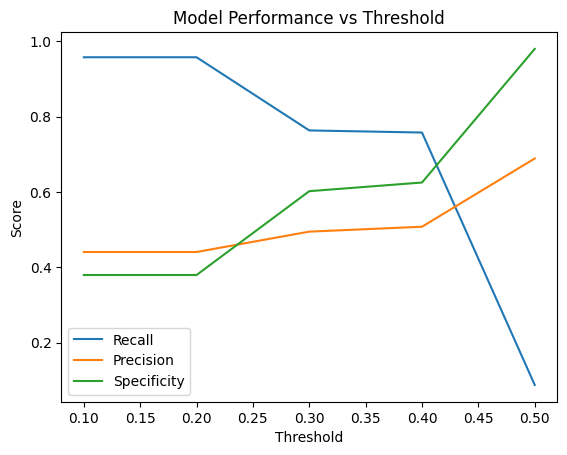

In [13]:
# Visualization
import matplotlib.pyplot as plt

plt.figure()

plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['specificity'], label='Specificity')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Model Performance vs Threshold")

plt.legend()
plt.show()

### Business Threshold Selection

The default threshold of 0.50 performs poorly for this problem, achieving only 8.7% recall, meaning the model fails to identify most defaulted loans.

To improve performance, multiple thresholds were evaluated:

- At 0.1–0.2, recall exceeds 95%, capturing nearly all defaults, but specificity drops significantly, leading to many false positives.
- At 0.3–0.4, the model achieves a better balance:
  - Recall: ~76%
  - Specificity: ~60–62%
  - Accuracy: ~66–67%

This range represents a more practical decision threshold for lending.

### Recommended Threshold

A threshold around 0.3–0.4 provides the best balance between:
- Identifying high-risk borrowers (recall)
- Avoiding excessive false alarms (specificity)

### Business Interpretation

In a lending context, missing a default is typically more costly than incorrectly flagging a safe loan.

Therefore, using a lower threshold than 0.50 allows lenders to:
- Detect a significantly higher proportion of risky loans
- Proactively manage credit risk
- Accept a reasonable increase in false positives as a tradeoff

This demonstrates that model performance should be evaluated based on business impact, not just default settings.